# Health Insurance Claims: What Is Associated with Higher Claims?

**A question-driven analysis of 1,340 policyholders**

---

## Project Overview

Insurers need to understand which characteristics are associated with larger claims. This project analyses 1,340 policyholders described by age, gender, BMI, blood pressure, diabetic status, number of children, smoking status and region, together with the amount they claimed.

The work is organised around one central puzzle: several attributes look related to claims in a simple comparison, but many of those relationships turn out to be **composition effects** (they appear because the attribute is correlated with smoking). The goal is to separate what genuinely matters from what only appears to.

**Business questions**

1. How large is the claim gap between smokers and non-smokers, and how much of total claims do smokers account for?
2. Does gender really affect claims, or is it a side-effect of who smokes?
3. How do blood pressure, BMI and diabetes relate to smoking, gender and region?
4. Do regional claim differences persist after accounting for smoking?
5. Does age matter?
6. Does the effect of BMI on claims depend on smoking status?
7. Is blood pressure related to claims independently of smoking?
8. Do diabetes and the number of children matter?
9. Which combination of factors explains claims best?
10. Which segments of policyholders account for the largest claims?

**Dataset:** insurance claims data (1,340 rows, 11 columns) used in the original exercise.
**Tools:** pandas, NumPy, Matplotlib, Seaborn, SciPy, statsmodels.

**Notebook flow:** Dataset Understanding → Data Quality → Data Preparation → Exploratory Analysis → Question-Driven Analysis → Key Insights → Conclusion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 30)

smoker_palette = {"No": "#4c72b0", "Yes": "#c44e52"}   # one colour per group, reused everywhere
usd = lambda v, _: f"${v:,.0f}"

## 1. Dataset Understanding

In [2]:
GSHEET_URL = ("https://docs.google.com/spreadsheets/d/e/2PACX-1vQVpcVtdYdZU4zU4-lqxt-iPHkyndDWs_aqEDUu9ZodlJ48Dku0PFgdXlj2N5RCmwXJrNtZLsI_wEVf/"
              "pub?gid=220677750&single=true&output=csv")
MIRROR_URL = "https://raw.githubusercontent.com/praveenkumarbarange/S1-SQL-Insurance-Claim-Analysis/main/insurance_data.csv"

def load_insurance():
    # Try the original source first; fall back to a public copy of the same file if it is unreachable.
    for name, url in [("original Google Sheet", GSHEET_URL), ("public GitHub copy of the same file", MIRROR_URL)]:
        try:
            data = pd.read_csv(url, index_col="index")
            print(f"Loaded from the {name}")
            return data
        except Exception:
            continue
    raise RuntimeError("Could not load the dataset from either source.")

raw = load_insurance()
print(f"Rows: {raw.shape[0]:,} | Columns: {raw.shape[1]}")
raw.head()

Loaded from the public GitHub copy of the same file
Rows: 1,340 | Columns: 10


,PatientID,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
index,,,,,,,,,,
0,1,39.00,male,23.20,91,Yes,0,No,southeast,"1,121.87"
1,2,24.00,male,30.10,87,No,0,No,southeast,"1,131.51"
2,3,NaN,male,33.30,82,Yes,0,No,southeast,"1,135.94"
3,4,NaN,male,33.70,80,No,0,No,northwest,"1,136.40"
4,5,NaN,male,34.10,100,No,0,No,northwest,"1,137.01"


**Data dictionary**

| Column | Type | Meaning |
|---|---|---|
| `PatientID` | integer | Row identifier (examined in the data-quality section) |
| `age` | numeric | Age in years |
| `gender` | category | male / female |
| `bmi` | numeric | Body mass index |
| `bloodpressure` | integer | Blood pressure reading (units not documented in the source) |
| `diabetic` | category | Yes / No |
| `children` | integer | Number of children |
| `smoker` | category | Yes / No |
| `region` | category | northeast / northwest / southeast / southwest |
| `claim` | numeric | Insurance claim amount in USD (the outcome of interest) |

In [3]:
raw.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PatientID,"1,340.00",NaN,NaN,NaN,670.50,386.97,1.00,335.75,670.50,"1,005.25","1,340.00"
age,"1,335.00",NaN,NaN,NaN,38.08,11.10,18.00,29.00,38.00,47.00,60.00
gender,1340,2,male,678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,"1,340.00",NaN,NaN,NaN,30.67,6.11,16.00,26.27,30.40,34.70,53.10
bloodpressure,"1,340.00",NaN,NaN,NaN,94.16,11.43,80.00,86.00,92.00,99.00,140.00
diabetic,1340,2,No,698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
children,"1,340.00",NaN,NaN,NaN,1.09,1.21,0.00,0.00,1.00,2.00,5.00
smoker,1340,2,No,1066,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1337,4,southeast,443,NaN,NaN,NaN,NaN,NaN,NaN,NaN
claim,"1,340.00",NaN,NaN,NaN,"13,252.75","12,109.61","1,121.87","4,719.68","9,369.61","16,604.31","63,770.43"


## 2. Data Quality

In [4]:
quality = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "% missing": raw.isna().mean() * 100,
    "unique_values": raw.nunique(),
})
display(quality)

print(f"Duplicate rows (ignoring PatientID): {raw.drop(columns='PatientID').duplicated().sum()}")
print(f"PatientID unique: {raw['PatientID'].is_unique}")

incomplete = raw[raw[["age", "region"]].isna().any(axis=1)]
print(f"\nRows with a missing age or region: {len(incomplete)} ({len(incomplete) / len(raw):.1%})")
print(f"Their claims range from ${incomplete['claim'].min():,.0f} to ${incomplete['claim'].max():,.0f} "
      f"(dataset minimum ${raw['claim'].min():,.0f}, median ${raw['claim'].median():,.0f})")

rho, _ = stats.spearmanr(raw["PatientID"], raw["claim"])
print(f"\nSpearman correlation between PatientID and claim: {rho:.4f}")

,dtype,missing,% missing,unique_values
PatientID,int64,0,0.00,1340
age,float64,5,0.37,43
gender,str,0,0.00,2
bmi,float64,0,0.00,275
bloodpressure,int64,0,0.00,61
diabetic,str,0,0.00,2
children,int64,0,0.00,6
smoker,str,0,0.00,2
region,str,3,0.22,4
claim,float64,0,0.00,1337


Duplicate rows (ignoring PatientID): 0
PatientID unique: True

Rows with a missing age or region: 8 (0.6%)
Their claims range from $1,136 to $1,256 (dataset minimum $1,122, median $9,370)

Spearman correlation between PatientID and claim: 0.9999


In [5]:
rows = []
for col in ["bmi", "bloodpressure", "claim"]:
    q1, q3 = raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = (raw[col] < q1 - 1.5 * iqr) | (raw[col] > q3 + 1.5 * iqr)
    rows.append({"variable": col, "outliers (1.5 x IQR)": mask.sum(), "% of rows": mask.mean() * 100,
                 "% of outliers who smoke": (raw.loc[mask, "smoker"] == "Yes").mean() * 100})
display(pd.DataFrame(rows).set_index("variable"))
print(f"Overall share of smokers: {(raw['smoker'] == 'Yes').mean():.1%}")

,outliers (1.5 x IQR),% of rows,% of outliers who smoke
variable,,,
bmi,9,0.67,33.33
bloodpressure,62,4.63,85.48
claim,141,10.52,97.87


Overall share of smokers: 20.4%


**Finding.**

- **Very clean overall:** no duplicates and only 8 missing values (5 in `age`, 3 in `region`; 0.6% of rows).
- **The file is sorted by claim amount.** `PatientID` has a Spearman correlation of 0.9999 with `claim`, so it is just a rank of the outcome and would leak the answer into any model. It is dropped. The missing values are also **not random**: all 8 rows sit at the very bottom of the claim range ($1,136 to $1,256). With only 8 rows the effect on conclusions is negligible, but it is why I exclude them rather than impute them.
- **Outliers are structure, not errors.** 10.5% of claims and 4.6% of blood-pressure readings are statistical outliers, but **98% of the claim outliers and 85% of the blood-pressure outliers are smokers** (smokers are 20% of the data). They reflect a distinct group rather than data-entry mistakes, so they are kept.
- **Plausibility flags.** Blood pressure never falls below 80 (a hard floor), and 48% of policyholders are diabetic, far above typical population rates. Both suggest the data may be synthetic or a selected sample, so findings describe this dataset rather than the general population.
- **Source.** The original Google Sheet was unreachable in the environment where this notebook was executed, so the loader falls back to a public copy of the same file (identical columns, 1,340 rows, matching the first rows shown in the original notebook).

## 3. Data Preparation

- Drop `PatientID` (it would leak the outcome).
- **Missing values:** only 8 rows (0.6%) have a missing age or region. I do not impute them; each analysis uses the rows that have the columns it needs.
- Add interpretable groupings: `bmi_category` (standard WHO cut-offs), `age_group`, `bp_band` (10-point bands, purely descriptive, since the blood-pressure units are undocumented) and `children_group`.

In [6]:
df = raw.drop(columns="PatientID").copy()

df["bmi_category"] = pd.cut(df["bmi"], bins=[0, 18.5, 25, 30, np.inf], right=False,
                            labels=["Underweight", "Normal", "Overweight", "Obese"])
df["age_group"] = pd.cut(df["age"], bins=[18, 30, 40, 50, 61], right=False, labels=["18–29", "30–39", "40–49", "50–60"])
df["bp_band"] = pd.cut(df["bloodpressure"], bins=[80, 90, 100, 110, np.inf], right=False,
                       labels=["80–89", "90–99", "100–109", "110+"])
df["children_group"] = pd.Categorical(df["children"].clip(upper=3).map({0: "0", 1: "1", 2: "2", 3: "3+"}),
                                      categories=["0", "1", "2", "3+"], ordered=True)
df["smoker"] = pd.Categorical(df["smoker"], categories=["No", "Yes"])

print(df["bmi_category"].value_counts().reindex(["Underweight", "Normal", "Overweight", "Obese"]).to_string())
df.head()

bmi_category
Underweight     20
Normal         223
Overweight     389
Obese          708


,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim,bmi_category,age_group,bp_band,children_group
index,,,,,,,,,,,,,
0,39.00,male,23.20,91,Yes,0,No,southeast,"1,121.87",Normal,30–39,90–99,0
1,24.00,male,30.10,87,No,0,No,southeast,"1,131.51",Obese,18–29,80–89,0
2,NaN,male,33.30,82,Yes,0,No,southeast,"1,135.94",Obese,NaN,80–89,0
3,NaN,male,33.70,80,No,0,No,northwest,"1,136.40",Obese,NaN,80–89,0
4,NaN,male,34.10,100,No,0,No,northwest,"1,137.01",Obese,NaN,100–109,0


## 4. Exploratory Analysis

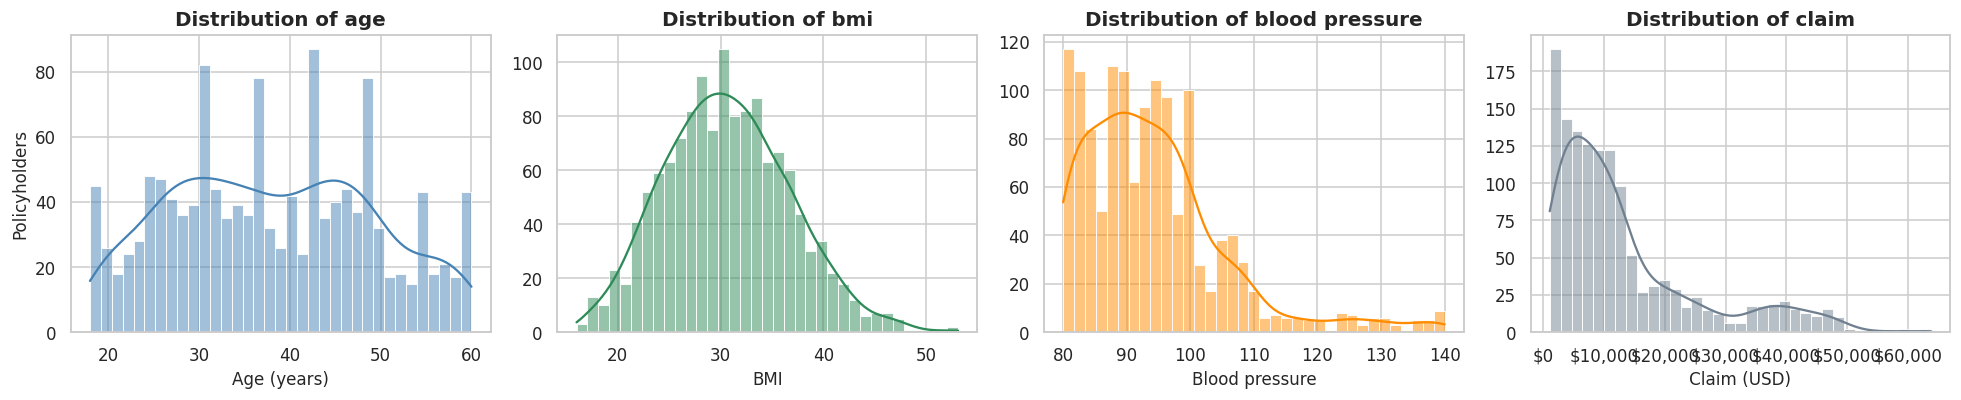

Claim skewness: 1.52 | median $9,370 | mean $13,253


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.8))
for ax, col, label, color in zip(axes, ["age", "bmi", "bloodpressure", "claim"],
                                 ["Age (years)", "BMI", "Blood pressure", "Claim (USD)"],
                                 ["steelblue", "seagreen", "darkorange", "slategray"]):
    sns.histplot(df[col], bins=35, kde=True, ax=ax, color=color)
    ax.set(title=f"Distribution of {label.split(' (')[0].lower()}", xlabel=label, ylabel="Policyholders" if col == "age" else "")
axes[3].xaxis.set_major_formatter(usd)
plt.tight_layout()
plt.show()

print(f"Claim skewness: {df['claim'].skew():.2f} | median ${df['claim'].median():,.0f} | mean ${df['claim'].mean():,.0f}")

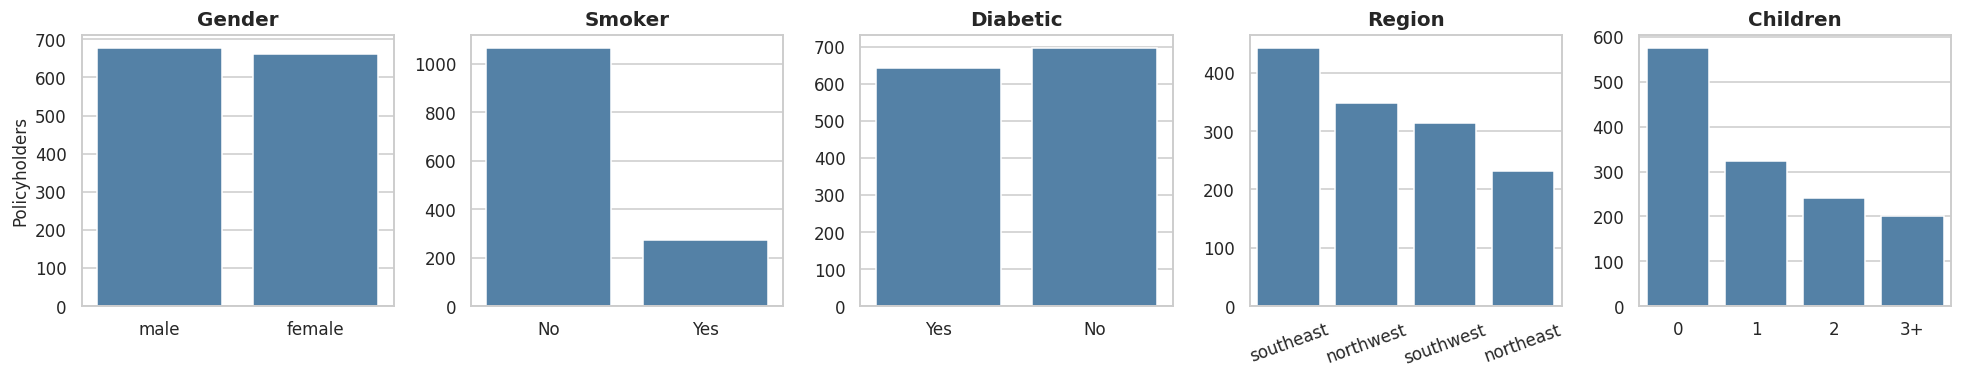

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6))
for ax, col in zip(axes, ["gender", "smoker", "diabetic", "region", "children_group"]):
    order = df[col].value_counts().index if col == "region" else None
    sns.countplot(data=df, x=col, order=order, color="steelblue", ax=ax)
    ax.set(title=col.replace("_group", "").capitalize(), xlabel="", ylabel="Policyholders" if col == "gender" else "")
    ax.tick_params(axis="x", rotation=20 if col == "region" else 0)
plt.tight_layout()
plt.show()

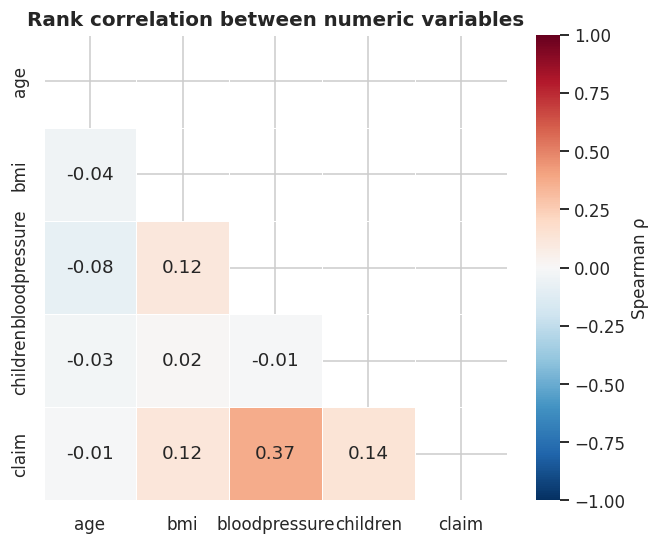

In [9]:
num_cols = ["age", "bmi", "bloodpressure", "children", "claim"]
corr = df[num_cols].corr(method="spearman")
plt.figure(figsize=(6.8, 5.5))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, linewidths=0.5, cbar_kws={"label": "Spearman ρ"})
plt.title("Rank correlation between numeric variables")
plt.show()

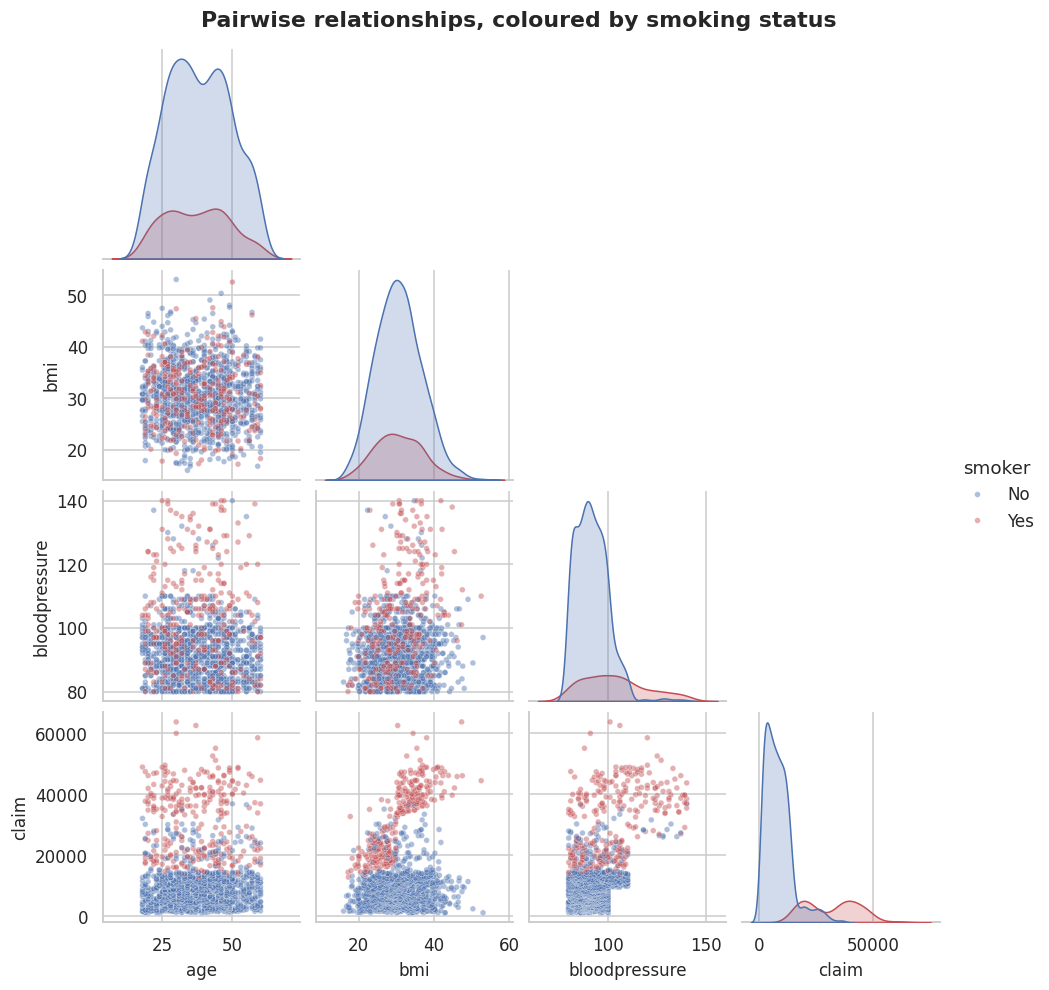

In [10]:
g = sns.pairplot(df[["age", "bmi", "bloodpressure", "claim", "smoker"]], hue="smoker", palette=smoker_palette,
                 corner=True, diag_kind="kde", plot_kws={"alpha": 0.45, "s": 14}, height=2.2)
g.figure.suptitle("Pairwise relationships, coloured by smoking status", y=1.02, fontweight="bold")
plt.show()

**Finding.**

- **Claims are right-skewed** (skewness 1.5): the median is $9,370 but the mean is $13,253, pulled up by a group of very large claims up to $63,770.
- **Age is roughly uniform from 18 to 60; BMI is centred near 30** (53% of policyholders are in the obese category, 708 people), and there are few underweight policyholders (20).
- **Smokers are a minority (20%)** and the southeast is the largest region (443 policyholders).
- **Blood pressure is the numeric variable most strongly correlated with claims** (Spearman 0.37; Pearson about 0.53). BMI is weaker (Pearson about 0.20), and age and children are close to zero.
- **The pairplot shows why:** claims separate into two distinct bands by smoking status, and the smoker band is also shifted in blood pressure. Most numeric relationships are therefore best read *within* smoking groups, which the questions below do.

## 5. Question-Driven Analysis

### Q1. How large is the claim gap between smokers and non-smokers?

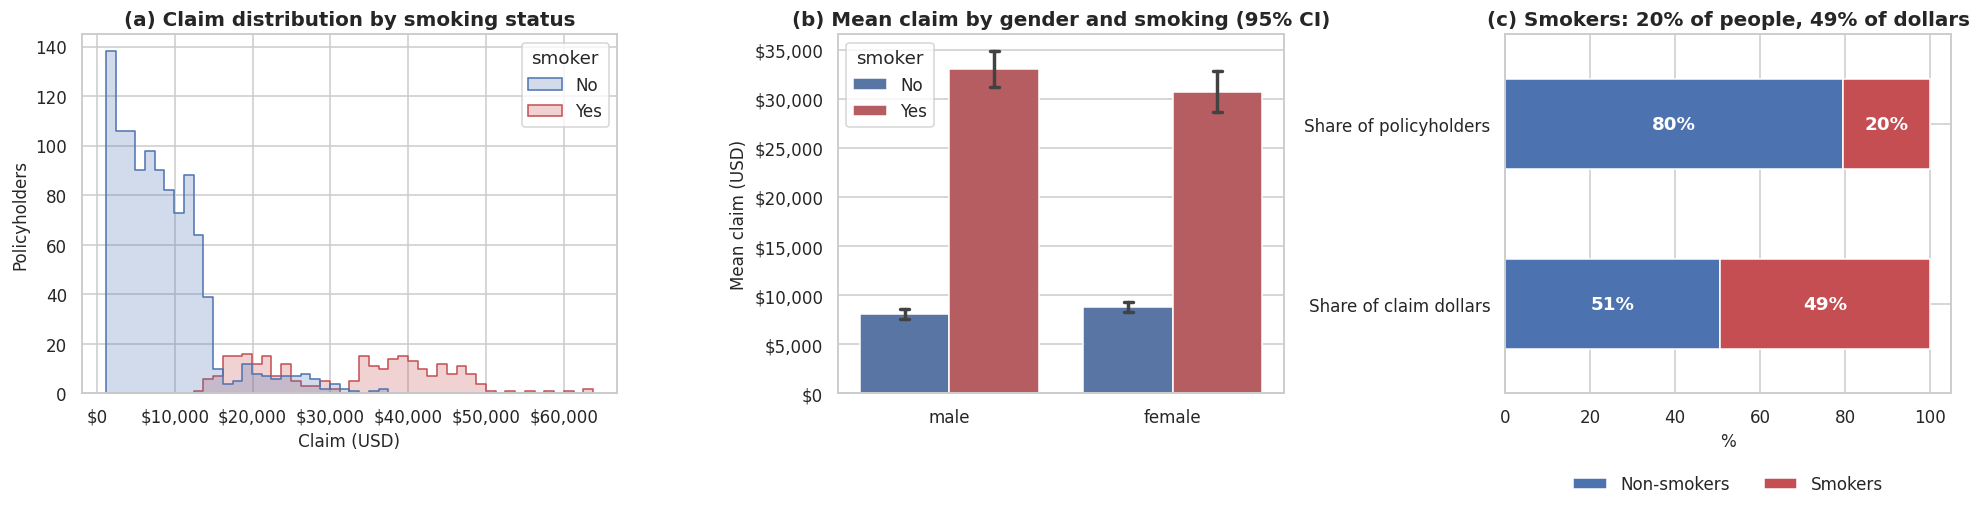

,size,mean,median,std,min,max
smoker,,,,,,
No,1066,"8,421.12","7,341.41","5,995.84","1,121.87","36,910.61"
Yes,274,"32,050.23","34,456.35","11,541.55","12,829.46","63,770.43"


Mean claim ratio (smokers / non-smokers): 3.8x
Mann-Whitney U test: p = 4.43e-130

Share of smokers among the top 10% of claims (134 policyholders): 97.8%


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={"width_ratios": [1.2, 1, 1]})

sns.histplot(data=df, x="claim", hue="smoker", hue_order=["No", "Yes"], palette=smoker_palette, bins=50,
             element="step", common_norm=False, ax=axes[0])
axes[0].set(title="(a) Claim distribution by smoking status", xlabel="Claim (USD)", ylabel="Policyholders")
axes[0].xaxis.set_major_formatter(usd)

sns.barplot(data=df, x="gender", y="claim", hue="smoker", hue_order=["No", "Yes"], palette=smoker_palette,
            errorbar=("ci", 95), capsize=0.08, ax=axes[1])
axes[1].set(title="(b) Mean claim by gender and smoking (95% CI)", xlabel="", ylabel="Mean claim (USD)")
axes[1].yaxis.set_major_formatter(usd)

shares = pd.DataFrame({
    "Share of policyholders": df["smoker"].value_counts(normalize=True),
    "Share of claim dollars": df.groupby("smoker", observed=True)["claim"].sum() / df["claim"].sum(),
}).T[["No", "Yes"]] * 100
shares = shares.iloc[::-1]
shares.plot(kind="barh", stacked=True, color=[smoker_palette["No"], smoker_palette["Yes"]], ax=axes[2])
for i, (_, row) in enumerate(shares.iterrows()):
    axes[2].text(row["No"] / 2, i, f"{row['No']:.0f}%", ha="center", va="center", color="white", fontweight="bold", fontsize=12)
    axes[2].text(row["No"] + row["Yes"] / 2, i, f"{row['Yes']:.0f}%", ha="center", va="center", color="white", fontweight="bold", fontsize=12)
axes[2].legend(["Non-smokers", "Smokers"], loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=2, frameon=False)
axes[2].set(title="(c) Smokers: 20% of people, 49% of dollars", xlabel="%", ylabel="")
plt.tight_layout()
plt.show()

summary = df.groupby("smoker", observed=True)["claim"].agg(["size", "mean", "median", "std", "min", "max"])
display(summary)
print(f"Mean claim ratio (smokers / non-smokers): {summary.loc['Yes', 'mean'] / summary.loc['No', 'mean']:.1f}x")
print(f"Mann-Whitney U test: p = {stats.mannwhitneyu(df.loc[df.smoker == 'Yes', 'claim'], df.loc[df.smoker == 'No', 'claim']).pvalue:.2e}")

top10 = df.nlargest(int(len(df) * 0.10), "claim")
print(f"\nShare of smokers among the top 10% of claims ({len(top10)} policyholders): {(top10['smoker'] == 'Yes').mean():.1%}")

**Finding.** Smoking is by far the strongest signal in the data.

- Smokers claim **$32,050 on average against $8,421 for non-smokers (3.8 times more)**, and the medians tell the same story ($34,456 vs $7,341).
- The distributions barely overlap: the smallest smoker claim ($12,829) is higher than 84% of non-smoker claims, and **98% of the top-10% claims (131 of 134) belong to smokers**.
- Smokers are 20% of policyholders but account for **about half (49%) of all claim dollars**.
- Non-smokers' claims cap at about $37,000, while smoker claims range from $12,800 to $63,800, which is also a much wider spread in absolute terms.

The difference is highly significant (p < 1e-100), but the more important point is its size: this is an effect large enough to dominate every other comparison in the dataset.

### Q2. Does gender affect claims, or is it a side-effect of who smokes?

Panel (b) above hints that the male-female gap changes direction depending on smoking status. I check this directly.

In [12]:
gender_tbl = df.pivot_table(index="gender", columns="smoker", values="claim", aggfunc="mean", observed=True)
gender_tbl["All"] = df.groupby("gender")["claim"].mean()
gender_tbl["Smoker share"] = df.groupby("gender")["smoker"].apply(lambda s: (s == "Yes").mean())
display(gender_tbl.rename_axis(columns=None).rename(columns={"No": "Non-smokers", "Yes": "Smokers"}))

m, f = df[df.gender == "male"], df[df.gender == "female"]
print(f"Overall mean claim: male ${m.claim.mean():,.0f} vs female ${f.claim.mean():,.0f} | medians: ${m.claim.median():,.0f} vs ${f.claim.median():,.0f}")
print(f"Mann-Whitney (overall):      p = {stats.mannwhitneyu(m.claim, f.claim).pvalue:.3f}")
for s in ["No", "Yes"]:
    a, b = m[m.smoker == s].claim, f[f.smoker == s].claim
    print(f"Mann-Whitney (smoker = {s:<3}): p = {stats.mannwhitneyu(a, b).pvalue:.3f}")
chi2, p, _, _ = stats.chi2_contingency(pd.crosstab(df["gender"], df["smoker"]))
print(f"Chi-square test, gender vs smoking: p = {p:.4f}")

,Non-smokers,Smokers,All,Smoker share
gender,,,,
female,"8,762.30","30,679.00","12,569.58",0.17
male,"8,061.54","33,042.01","13,919.79",0.23


Overall mean claim: male $13,920 vs female $12,570 | medians: $9,333 vs $9,413
Mann-Whitney (overall):      p = 0.799
Mann-Whitney (smoker = No ): p = 0.013
Mann-Whitney (smoker = Yes): p = 0.110
Chi-square test, gender vs smoking: p = 0.0071


**Finding.** Gender is a weak factor whose apparent effect changes depending on how you look at it:

- Overall, men claim more on average ($13,920 vs $12,570), but the **medians are almost identical** ($9,333 vs $9,413) and the difference is not significant (p = 0.80).
- **Men smoke more (23% vs 17%; chi-square p = 0.007)**, and because smokers claim so much more, this alone lifts the male average.
- Within non-smokers, **women actually claim slightly more** ($8,762 vs $8,062, p = 0.013). Among smokers the male-female difference goes the other way and is not significant (p = 0.11).

So the male average is high because of who smokes, not because of gender itself. The within-group differences are small compared with the smoker gap, and this is a good example of why comparisons should account for a dominant confounder.

### Q3. How does blood pressure relate to smoking and gender?

Blood pressure by gender, split by smoking status. A box plot summarises each group and the individual points are overlaid so that the sample size and spread stay visible.

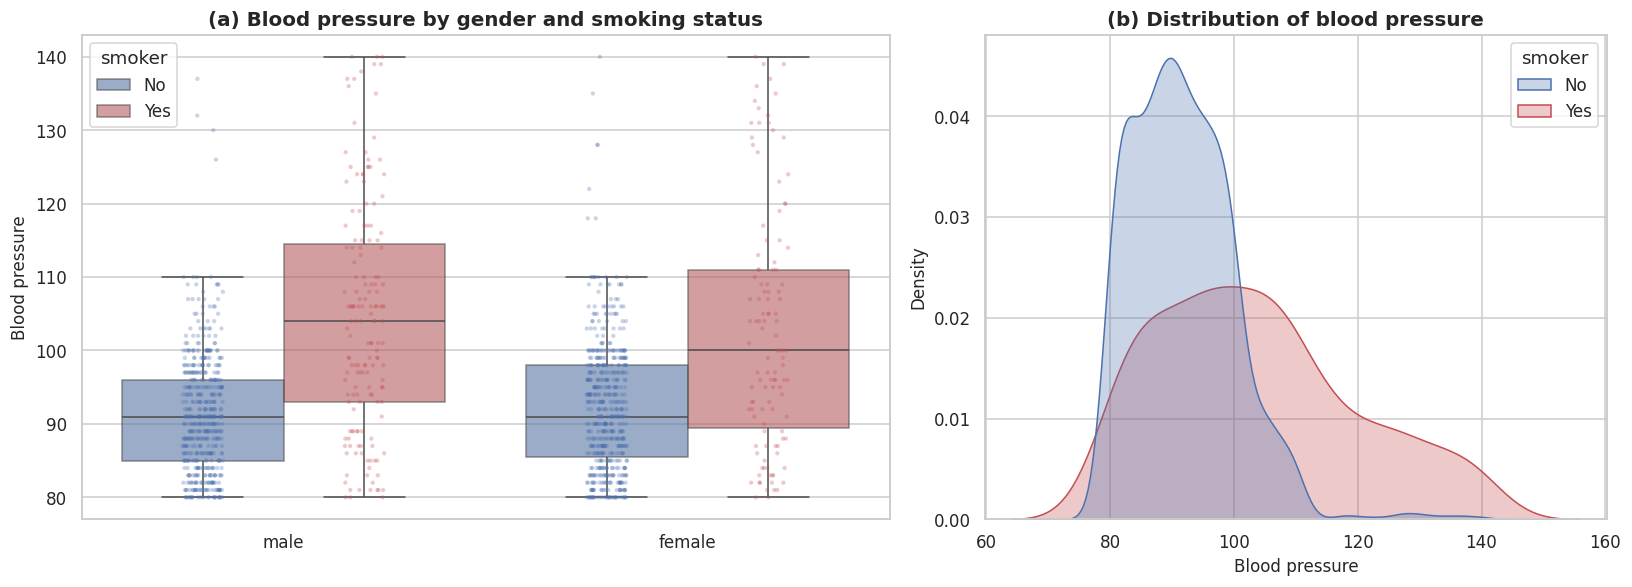

size   mean  median
smoker gender                     
No     female   547  92.16   91.00
       male     519  91.29   91.00
Yes    female   115 102.85  100.00
       male     159 104.12  104.00

Mann-Whitney, smokers vs non-smokers: p = 1.02e-30
Mann-Whitney, male vs female:        p = 0.951
Share with blood pressure >= 110: smokers 30.3% vs non-smokers 2.2%


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), gridspec_kw={"width_ratios": [1.3, 1]})

sns.boxplot(data=df, x="gender", y="bloodpressure", hue="smoker", hue_order=["No", "Yes"], palette=smoker_palette,
            showfliers=False, boxprops={"alpha": 0.6}, ax=axes[0])
sns.stripplot(data=df, x="gender", y="bloodpressure", hue="smoker", hue_order=["No", "Yes"], palette=smoker_palette,
              dodge=True, alpha=0.3, size=2.8, legend=False, ax=axes[0])
axes[0].set(title="(a) Blood pressure by gender and smoking status", xlabel="", ylabel="Blood pressure")

sns.kdeplot(data=df, x="bloodpressure", hue="smoker", hue_order=["No", "Yes"], palette=smoker_palette,
            common_norm=False, fill=True, alpha=0.3, ax=axes[1])
axes[1].set(title="(b) Distribution of blood pressure", xlabel="Blood pressure", ylabel="Density")
plt.tight_layout()
plt.show()

bp = df.groupby(["smoker", "gender"], observed=True)["bloodpressure"].agg(["size", "mean", "median"])
display(bp)
s_yes, s_no = df[df.smoker == "Yes"].bloodpressure, df[df.smoker == "No"].bloodpressure
print(f"Mann-Whitney, smokers vs non-smokers: p = {stats.mannwhitneyu(s_yes, s_no).pvalue:.2e}")
print(f"Mann-Whitney, male vs female:        p = {stats.mannwhitneyu(df[df.gender == 'male'].bloodpressure, df[df.gender == 'female'].bloodpressure).pvalue:.3f}")
print(f"Share with blood pressure >= 110: smokers {(s_yes >= 110).mean():.1%} vs non-smokers {(s_no >= 110).mean():.1%}")

**Finding.** Blood pressure is tied to smoking, not to gender.

- Smokers have much higher blood pressure (mean about 104 vs 92; p < 1e-30), and their distribution has a long right tail. **30% of smokers have a reading of 110 or above, against 2% of non-smokers.**
- Male and female patients have virtually the same blood pressure (p = 0.95), and the box plots look alike once smoking is separated.
- The non-smoker distribution is narrow (mostly 80 to 100, with a few outliers), while the smoker distribution is wide, so smoking also increases the *variability* of blood pressure.

The strip overlay shows the smoker groups are much smaller than the non-smoker groups (115 to 159 vs 519 to 547 policyholders), so the exact medians there are less certain. This matters for Q8, where blood pressure and smoking would otherwise be confused.

### Q4. How does BMI vary by region and diabetic status?

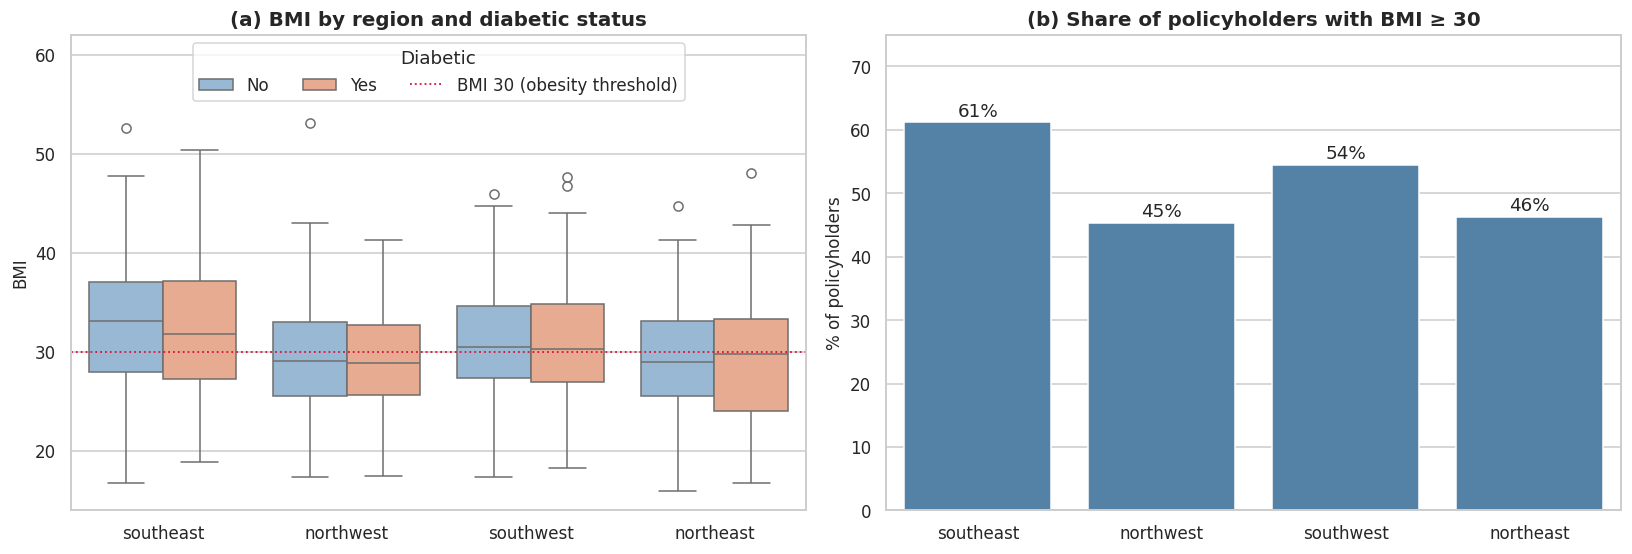

,policyholders,mean_bmi,median_bmi,smoker_share,mean_claim
region,,,,,
southeast,443,32.39,32.10,0.21,"13,058.52"
northwest,349,29.27,28.90,0.17,"11,672.09"
southwest,314,30.78,30.50,0.18,"12,723.13"
northeast,231,29.36,29.60,0.29,"16,889.04"


Kruskal-Wallis, BMI across regions:       p = 4.23e-12
Mann-Whitney, BMI diabetic vs non-diabetic: p = 0.169 (means 30.4 vs 30.9)


In [14]:
region_order = df["region"].value_counts().index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sns.boxplot(data=df.dropna(subset=["region"]), x="region", y="bmi", order=region_order, hue="diabetic",
            hue_order=["No", "Yes"], palette=["#8fb8de", "#f4a582"], ax=axes[0])
axes[0].set(title="(a) BMI by region and diabetic status", xlabel="", ylabel="BMI")
axes[0].axhline(30, color="crimson", ls=":", lw=1.2, label="BMI 30 (obesity threshold)")
axes[0].set_ylim(14, 62)
axes[0].legend(title="Diabetic", loc="upper center", ncol=3)

obese = df.dropna(subset=["region"]).groupby("region")["bmi"].apply(lambda s: (s >= 30).mean() * 100).reindex(region_order)
sns.barplot(x=obese.index, y=obese.values, color="steelblue", ax=axes[1])
for i, v in enumerate(obese.values):
    axes[1].text(i, v + 1, f"{v:.0f}%", ha="center")
axes[1].set(title="(b) Share of policyholders with BMI ≥ 30", xlabel="", ylabel="% of policyholders", ylim=(0, 75))
plt.tight_layout()
plt.show()

region_tbl = df.dropna(subset=["region"]).groupby("region").agg(
    policyholders=("bmi", "size"), mean_bmi=("bmi", "mean"), median_bmi=("bmi", "median"),
    smoker_share=("smoker", lambda s: (s == "Yes").mean()), mean_claim=("claim", "mean")).loc[region_order]
display(region_tbl)

print(f"Kruskal-Wallis, BMI across regions:       p = {stats.kruskal(*[g.bmi.values for _, g in df.groupby('region')]).pvalue:.2e}")
d_yes, d_no = df[df.diabetic == "Yes"].bmi, df[df.diabetic == "No"].bmi
print(f"Mann-Whitney, BMI diabetic vs non-diabetic: p = {stats.mannwhitneyu(d_yes, d_no).pvalue:.3f} (means {d_yes.mean():.1f} vs {d_no.mean():.1f})")

**Finding.**

- **BMI differs meaningfully by region** (Kruskal-Wallis p < 1e-11): the **southeast is highest (mean 32.4; 61% of policyholders have BMI ≥ 30)**, compared with 45% to 54% elsewhere (northwest 45%, northeast 46%, southwest 54%).
- **Diabetic status is unrelated to BMI in this dataset** (mean 30.4 vs 30.9, p = 0.17), and the pattern is the same in every region. This is unexpected in real populations, where BMI and diabetes are usually related, and is one more sign that the data is probably synthetic.
- The northeast has the fewest policyholders (231) and the highest smoker share (29%), which becomes important in the next question.

### Q5. Do regional claim differences persist after accounting for smoking?

The regional table above showed the northeast with both the highest average claim and the highest share of smokers. I check whether smoking alone explains the gap.

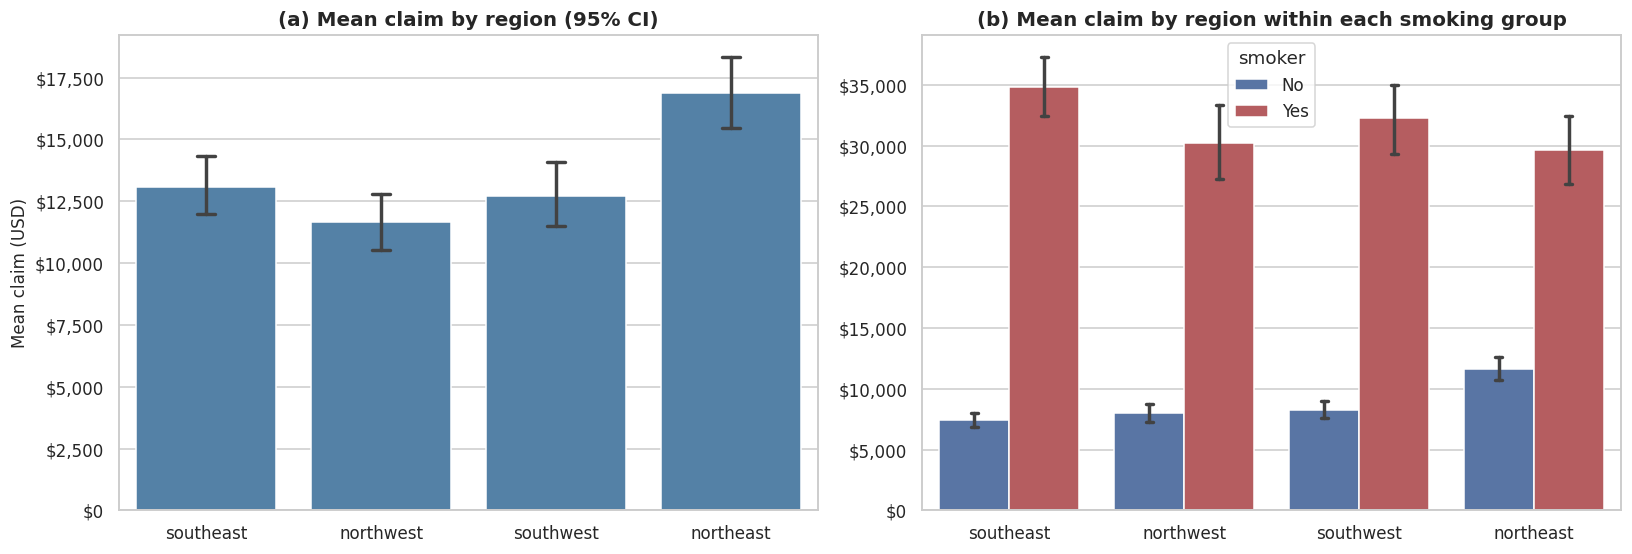

,"n, non-smokers","n, smokers","mean claim, non-smokers","mean claim, smokers"
region,,,,
southeast,352,91,"7,426.22","34,845.00"
northwest,291,58,"7,980.83","30,192.00"
southwest,256,58,"8,294.75","32,269.06"
northeast,164,67,"11,666.11","29,673.54"


Kruskal-Wallis, claims across regions, non-smokers only: p = 2.29e-16
Kruskal-Wallis, claims across regions, smokers only:     p = 0.019


In [15]:
reg = df.dropna(subset=["region"])
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sns.barplot(data=reg, x="region", y="claim", order=region_order, color="steelblue", errorbar=("ci", 95), capsize=0.1, ax=axes[0])
axes[0].set(title="(a) Mean claim by region (95% CI)", xlabel="", ylabel="Mean claim (USD)")
axes[0].yaxis.set_major_formatter(usd)

sns.barplot(data=reg, x="region", y="claim", order=region_order, hue="smoker", hue_order=["No", "Yes"],
            palette=smoker_palette, errorbar=("ci", 95), capsize=0.08, ax=axes[1])
axes[1].set(title="(b) Mean claim by region within each smoking group", xlabel="", ylabel="")
axes[1].yaxis.set_major_formatter(usd)
plt.tight_layout()
plt.show()

tbl = reg.pivot_table(index="region", columns="smoker", values="claim", aggfunc=["size", "mean"], observed=True).loc[region_order]
tbl.columns = [f"{'n' if a == 'size' else 'mean claim'}, {'smokers' if b == 'Yes' else 'non-smokers'}" for a, b in tbl.columns]
display(tbl)

ns = reg[reg.smoker == "No"]
print(f"Kruskal-Wallis, claims across regions, non-smokers only: p = {stats.kruskal(*[g.claim.values for _, g in ns.groupby('region')]).pvalue:.2e}")
sm = reg[reg.smoker == "Yes"]
print(f"Kruskal-Wallis, claims across regions, smokers only:     p = {stats.kruskal(*[g.claim.values for _, g in sm.groupby('region')]).pvalue:.3f}")

**Finding.** Smoking explains **part** of the regional pattern, not all of it.

- The northeast has the highest average claim ($16,889 vs $11,672 to $13,059 elsewhere), and it also has the highest share of smokers (29% vs 17% to 21%). Part of the gap is therefore composition.
- But **among non-smokers, the northeast still claims clearly more ($11,666 vs $7,426 to $8,295 elsewhere, about 40% to 57% higher; p < 1e-15).** Among smokers the northeast is actually the *lowest* ($29,674 vs up to $34,845 in the southeast; p = 0.02).
- Northeast non-smokers are also not distinguished by BMI (the northeast has one of the lowest average BMIs), so BMI does not explain it either.

The data cannot say why. Candidate explanations (cost of care, coverage differences, unrecorded risk factors) are not measured here. The regression in Q10 confirms that the regional effect remains after adjusting for the other variables.

### Q6. Does age matter?

Age is checked against BMI and against claims. In many insurance settings age is a major factor, so it is worth testing explicitly.

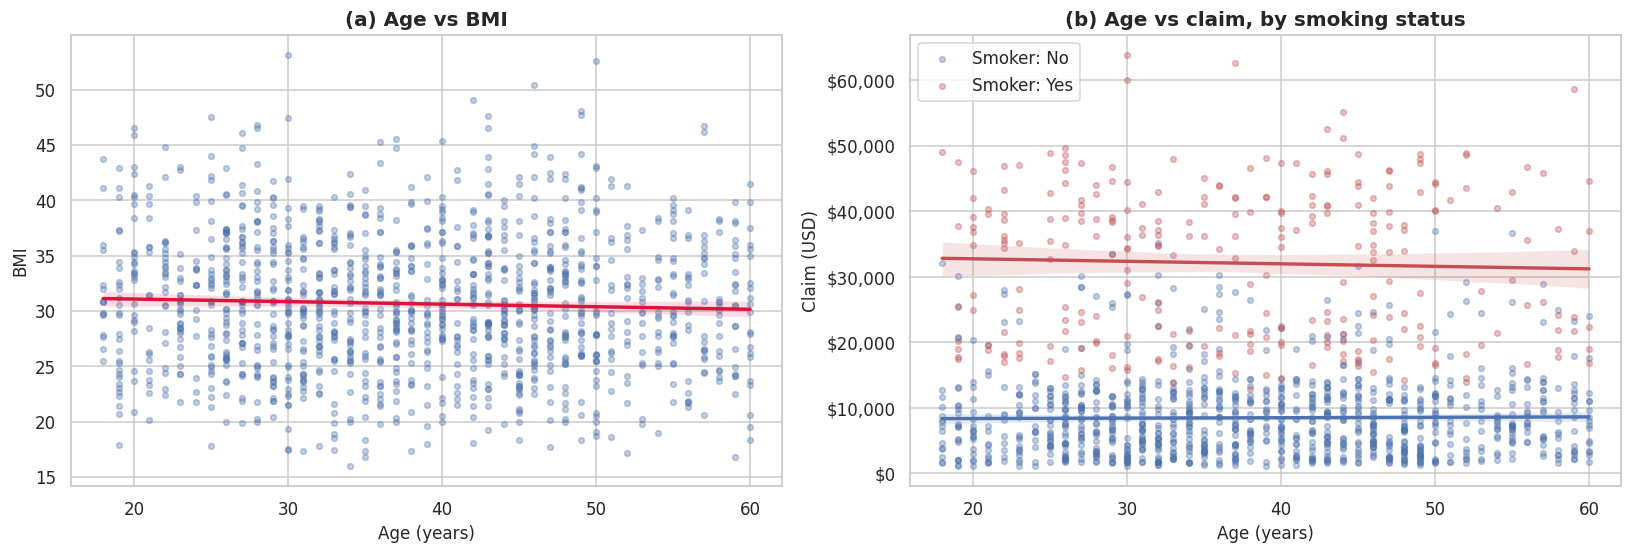

Age vs BMI:   Pearson r = -0.042, Spearman ρ = -0.043
Age vs claim: Pearson r = -0.028, Spearman ρ = -0.009
  smoker = No : r = 0.011 (n = 1061)
  smoker = Yes: r = -0.037 (n = 274)


,policyholders,mean_claim,median_claim,smoker_share
age_group,,,,
18–29,352,"13,950.55","9,466.53",0.23
30–39,372,"13,027.60","9,398.58",0.19
40–49,387,"13,142.65","9,283.56",0.21
50–60,224,"12,990.75","9,575.44",0.18


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
sns.regplot(data=df, x="age", y="bmi", scatter_kws={"alpha": 0.35, "s": 14}, line_kws={"color": "crimson"}, ax=axes[0])
axes[0].set(title="(a) Age vs BMI", xlabel="Age (years)", ylabel="BMI")

for s in ["No", "Yes"]:
    sns.regplot(data=df[df.smoker == s], x="age", y="claim", scatter_kws={"alpha": 0.35, "s": 14},
                line_kws={"linewidth": 2.2}, color=smoker_palette[s], label=f"Smoker: {s}", ax=axes[1])
axes[1].set(title="(b) Age vs claim, by smoking status", xlabel="Age (years)", ylabel="Claim (USD)")
axes[1].yaxis.set_major_formatter(usd)
axes[1].legend()
plt.tight_layout()
plt.show()

d = df.dropna(subset=["age"])
print(f"Age vs BMI:   Pearson r = {d.age.corr(d.bmi):.3f}, Spearman ρ = {d.age.corr(d.bmi, method='spearman'):.3f}")
print(f"Age vs claim: Pearson r = {d.age.corr(d.claim):.3f}, Spearman ρ = {d.age.corr(d.claim, method='spearman'):.3f}")
for s in ["No", "Yes"]:
    x = d[d.smoker == s]
    print(f"  smoker = {s:<3}: r = {x.age.corr(x.claim):.3f} (n = {len(x)})")
d.groupby("age_group", observed=True).agg(policyholders=("claim", "size"), mean_claim=("claim", "mean"), median_claim=("claim", "median"),
                                          smoker_share=("smoker", lambda s: (s == "Yes").mean()))

**Finding.** **Age shows no relationship with either BMI or claims**: correlations are close to zero (age vs BMI r = -0.04, age vs claim r = -0.03), the fitted lines are flat, and this holds within both smoker and non-smoker groups. Mean claims vary only between about $13,000 and $14,000 across the four age groups, and the smoker share is similar in each.

In real insurance data, age is usually one of the strongest cost drivers, so this result is another indication that the dataset is synthetic or built without an age effect. For this dataset the practical conclusion is simply that **age adds no information about claims**, and any model or pricing rule based on it would be unsupported by these data.

### Q7. Does the effect of BMI on claims depend on smoking status?

BMI has a modest overall correlation with claims (about 0.2). The pairplot suggested this might hide a group-specific relationship, so BMI is examined separately for smokers and non-smokers.

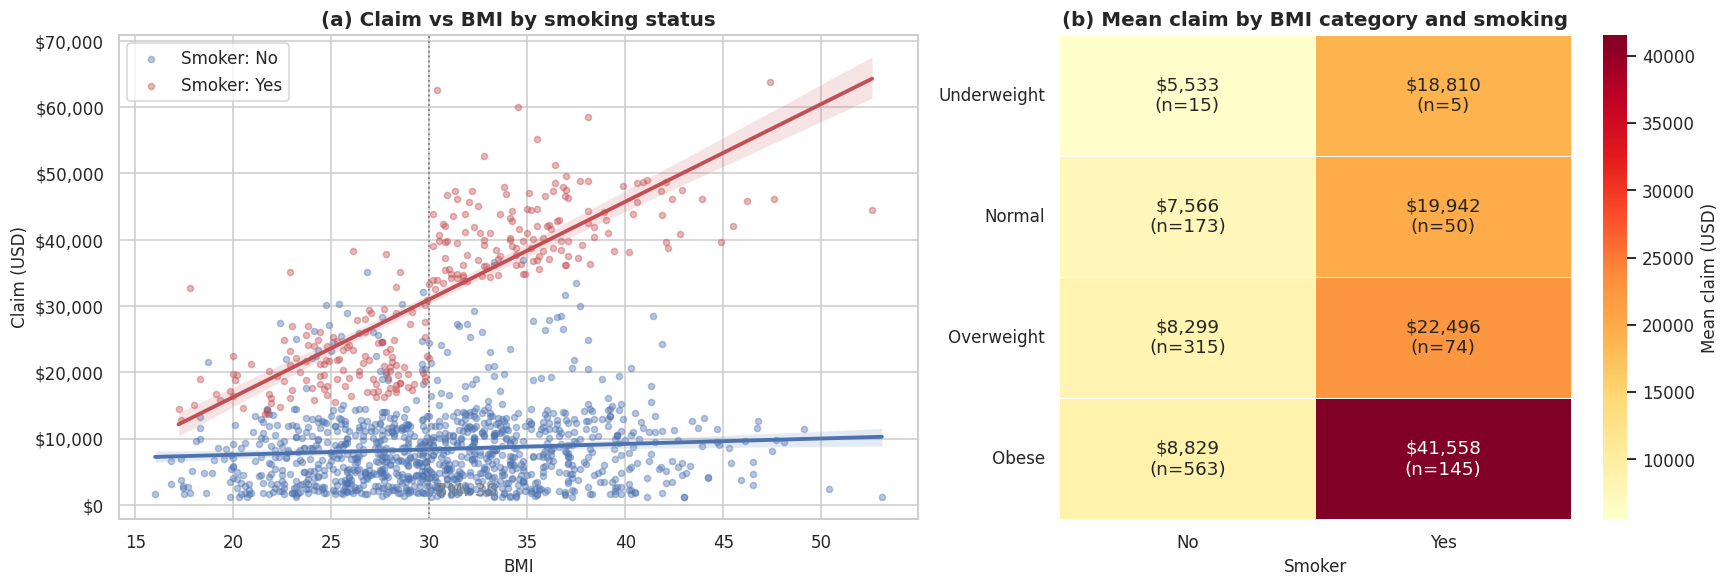

,policyholders,USD per BMI point,correlation r,R²
smoker,,,,
No,1066,81.81,0.08,0.01
Yes,274,"1,473.12",0.81,0.65


Smokers with BMI < 30: mean claim $21,363 (n=129) | BMI >= 30: $41,558 (n=145) | Mann-Whitney p = 1.08e-44


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1.25, 1]})
for s in ["No", "Yes"]:
    sns.regplot(data=df[df.smoker == s], x="bmi", y="claim", scatter_kws={"alpha": 0.4, "s": 16},
                line_kws={"linewidth": 2.5}, color=smoker_palette[s], label=f"Smoker: {s}", ax=axes[0])
axes[0].axvline(30, color="gray", ls=":", lw=1.2)
axes[0].text(30.3, axes[0].get_ylim()[1] * 0.02, "BMI 30", color="gray")
axes[0].set(title="(a) Claim vs BMI by smoking status", xlabel="BMI", ylabel="Claim (USD)")
axes[0].yaxis.set_major_formatter(usd)
axes[0].legend()

heat = df.pivot_table(index="bmi_category", columns="smoker", values="claim", aggfunc="mean", observed=True)
counts = df.pivot_table(index="bmi_category", columns="smoker", values="claim", aggfunc="size", observed=True)
labels = heat.map(lambda v: f"${v:,.0f}") + "\n(n=" + counts.astype(str) + ")"
sns.heatmap(heat, annot=labels, fmt="", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "Mean claim (USD)"}, ax=axes[1])
axes[1].set(title="(b) Mean claim by BMI category and smoking", xlabel="Smoker", ylabel="")
axes[1].tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

rows = []
for s in ["No", "Yes"]:
    x = df[df.smoker == s]
    r = stats.linregress(x["bmi"], x["claim"])
    rows.append({"smoker": s, "policyholders": len(x), "USD per BMI point": r.slope, "correlation r": r.rvalue, "R²": r.rvalue ** 2})
display(pd.DataFrame(rows).set_index("smoker"))

sm = df[df.smoker == "Yes"]
lo, hi = sm[sm.bmi < 30].claim, sm[sm.bmi >= 30].claim
print(f"Smokers with BMI < 30: mean claim ${lo.mean():,.0f} (n={len(lo)}) | BMI >= 30: ${hi.mean():,.0f} (n={len(hi)}) | Mann-Whitney p = {stats.mannwhitneyu(lo, hi).pvalue:.2e}")

**Finding.** BMI matters, but **only for smokers**, which is an interaction effect.

- For non-smokers, each additional BMI point is associated with about **$82** more in claims (r = 0.08, R² = 0.01): practically flat.
- For smokers, each BMI point is associated with about **$1,473** more (r = 0.81, R² = 0.65): steep and tight.
- Smokers with BMI below 30 average **$21,363**, and smokers with BMI of 30 or above average **$41,558**, almost double (p < 1e-40). The scatter suggests a step-like increase near BMI 30 rather than a smooth line, though the data cannot prove that threshold.
- The heatmap shows the obese smoker cell ($41,558, n = 145) far above every other cell, while for non-smokers the BMI categories differ by only about $1,300 between normal and obese.

This is why the overall correlation of BMI with claims looks modest (about 0.2): it is an average of a strong effect in 20% of the population and almost none in the rest. It is the most important non-obvious finding in the analysis.

### Q8. Is blood pressure related to claims independently of smoking?

Blood pressure is higher among smokers (Q3), so a simple correlation with claims could just be re-detecting smoking. I check within each smoking group.

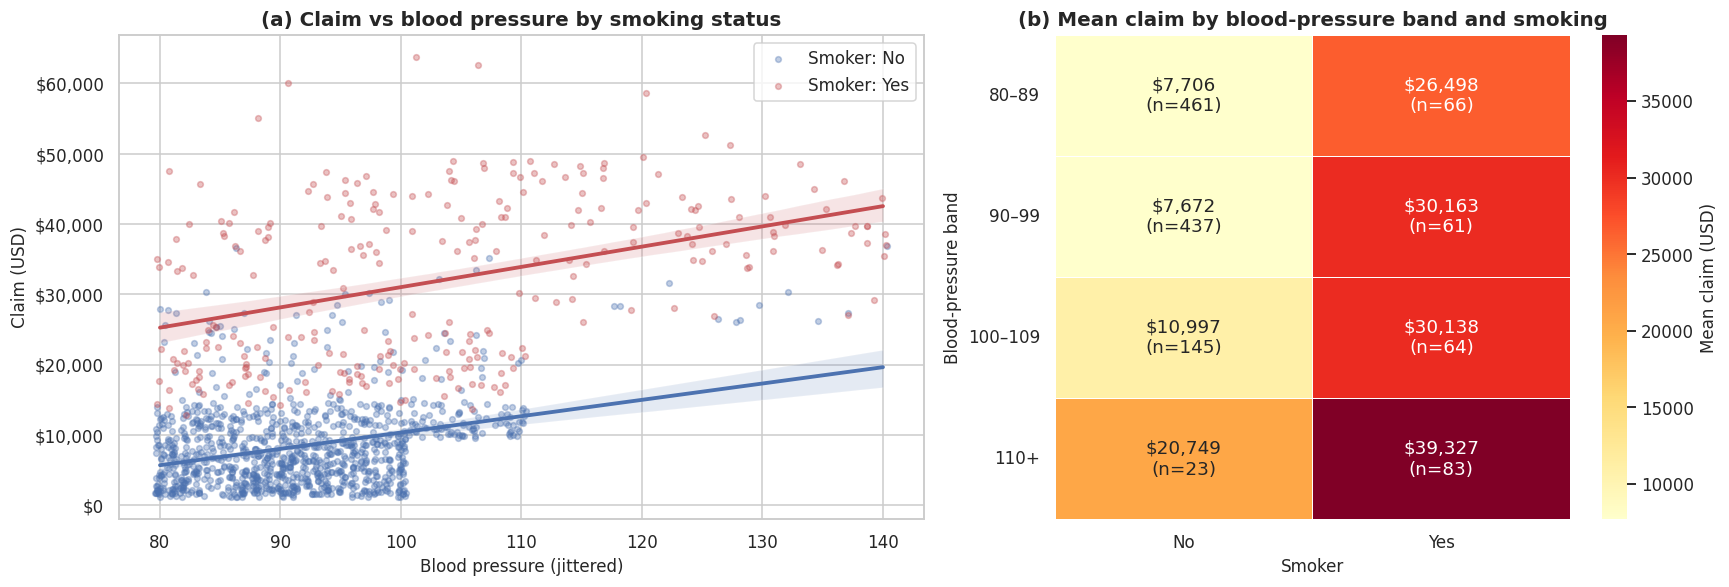

Overall:       Spearman ρ (blood pressure, claim) = 0.37
Smoker = No :  Spearman ρ = 0.22  (n = 1066)
Smoker = Yes:  Spearman ρ = 0.41  (n = 274)


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), gridspec_kw={"width_ratios": [1.25, 1]})
for s in ["No", "Yes"]:
    sns.regplot(data=df[df.smoker == s], x="bloodpressure", y="claim", x_jitter=0.4,
                scatter_kws={"alpha": 0.35, "s": 14}, line_kws={"linewidth": 2.5},
                color=smoker_palette[s], label=f"Smoker: {s}", ax=axes[0])
axes[0].set(title="(a) Claim vs blood pressure by smoking status", xlabel="Blood pressure (jittered)", ylabel="Claim (USD)")
axes[0].yaxis.set_major_formatter(usd)
axes[0].legend()

heat = df.pivot_table(index="bp_band", columns="smoker", values="claim", aggfunc="mean", observed=True)
counts = df.pivot_table(index="bp_band", columns="smoker", values="claim", aggfunc="size", observed=True)
labels = heat.map(lambda v: f"${v:,.0f}") + "\n(n=" + counts.astype(str) + ")"
sns.heatmap(heat, annot=labels, fmt="", cmap="YlOrRd", linewidths=0.5, cbar_kws={"label": "Mean claim (USD)"}, ax=axes[1])
axes[1].set(title="(b) Mean claim by blood-pressure band and smoking", xlabel="Smoker", ylabel="Blood-pressure band")
axes[1].tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()

print(f"Overall:       Spearman ρ (blood pressure, claim) = {df.bloodpressure.corr(df.claim, method='spearman'):.2f}")
for s in ["No", "Yes"]:
    x = df[df.smoker == s]
    print(f"Smoker = {s:<3}:  Spearman ρ = {x.bloodpressure.corr(x.claim, method='spearman'):.2f}  (n = {len(x)})")

**Finding.** Blood pressure has a **genuine relationship with claims, over and above smoking**, although smoking status exaggerates it in the raw view.

- The overall rank correlation is 0.37, but it remains positive within each group: **0.22 for non-smokers and 0.41 for smokers**.
- Among smokers, mean claims rise from about $26,500 for readings of 80 to 89 to about $39,300 for readings of 110 and above.
- Part of the raw correlation (0.37) is therefore smoking showing through blood pressure, but not all of it. The regression in Q10 estimates roughly $159 more in claims per blood-pressure point after adjusting for the other variables.

Because blood pressure's units are undocumented, and blood pressure could plausibly be a consequence of smoking, I interpret this as an association that is useful for risk segmentation, not as evidence that lowering blood pressure would lower claims.

### Q9. Do diabetes and the number of children matter?

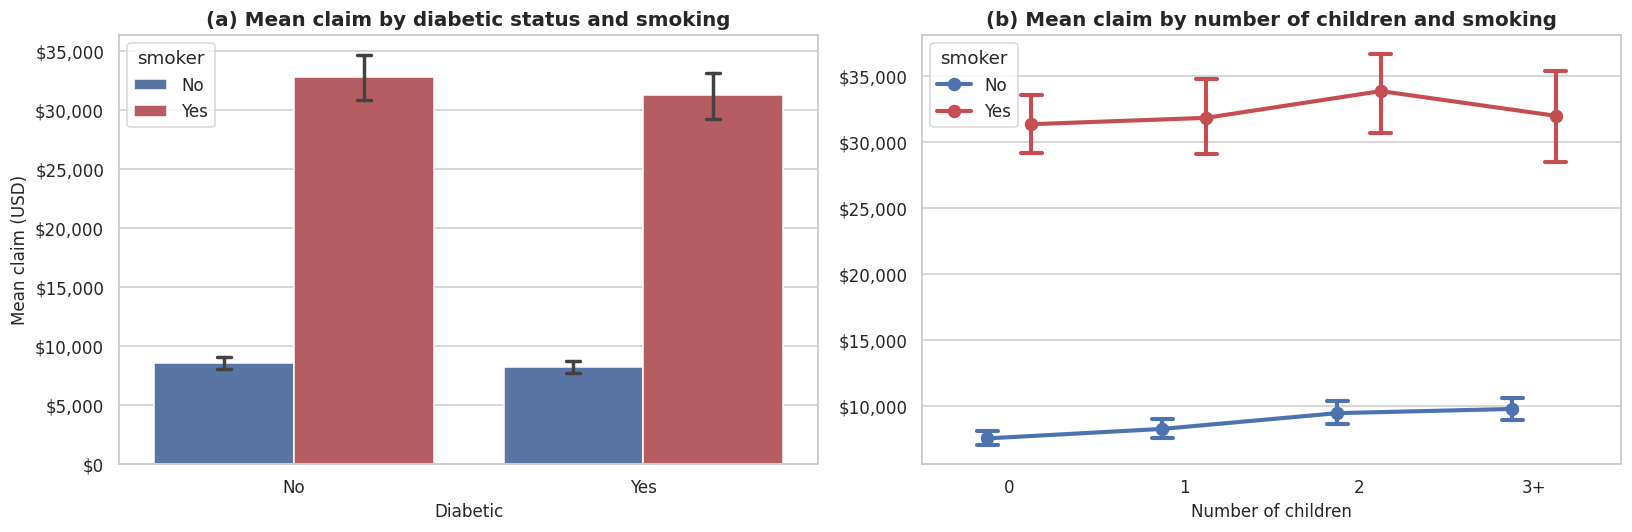

Diabetic vs non-diabetic, all policyholders: mean $13,143 vs $13,354, Mann-Whitney p = 0.86
Children vs claim, smoker = No : Spearman ρ = 0.18, p = 0.000
Children vs claim, smoker = Yes: Spearman ρ = 0.09, p = 0.151



size          mean          
smoker           No  Yes       No       Yes
children_group                             
0               461  115 7,585.00 31,341.00
1               263   61 8,303.00 31,823.00
2               185   55 9,493.00 33,844.00
3+              157   43 9,811.00 31,974.00

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=df, x="diabetic", y="claim", hue="smoker", hue_order=["No", "Yes"], order=["No", "Yes"],
            palette=smoker_palette, errorbar=("ci", 95), capsize=0.08, ax=axes[0])
axes[0].set(title="(a) Mean claim by diabetic status and smoking", xlabel="Diabetic", ylabel="Mean claim (USD)")
axes[0].yaxis.set_major_formatter(usd)

sns.pointplot(data=df, x="children_group", y="claim", hue="smoker", hue_order=["No", "Yes"],
              palette=smoker_palette, errorbar=("ci", 95), capsize=0.12, dodge=0.25, ax=axes[1])
axes[1].set(title="(b) Mean claim by number of children and smoking", xlabel="Number of children", ylabel="")
axes[1].yaxis.set_major_formatter(usd)
plt.tight_layout()
plt.show()

print(f"Diabetic vs non-diabetic, all policyholders: mean ${df[df.diabetic == 'Yes'].claim.mean():,.0f} vs ${df[df.diabetic == 'No'].claim.mean():,.0f}, "
      f"Mann-Whitney p = {stats.mannwhitneyu(df[df.diabetic == 'Yes'].claim, df[df.diabetic == 'No'].claim).pvalue:.2f}")
for s in ["No", "Yes"]:
    x = df[df.smoker == s]
    rho, p = stats.spearmanr(x["children"], x["claim"])
    print(f"Children vs claim, smoker = {s:<3}: Spearman ρ = {rho:.2f}, p = {p:.3f}")

print()
display(df.pivot_table(index="children_group", columns="smoker", values="claim", aggfunc=["size", "mean"], observed=True).round(0))

**Finding.**

- **Diabetes is not associated with claims** (mean $13,143 vs $13,354, p = 0.86), and the bars are indistinguishable in both smoking groups. The 48% diabetic share is large, so this null result is well-powered.
- **Number of children has a modest positive association for non-smokers only**: mean claims rise from $7,585 (no children) to $9,811 (three or more), Spearman ρ = 0.18 (p < 0.001). Among smokers there is no clear trend (ρ = 0.09, p = 0.15). Groups with 3 or more children are pooled because the 4 to 5 children groups are small (43 policyholders for smokers, 157 for non-smokers with 3+).
- The effect is small in dollar terms (roughly $700 per additional child in the regression), and it is much smaller than any smoking, BMI or blood-pressure effect.

### Q10. Which combination of factors explains claims best?

Linear regression is used descriptively to show how much of the variation in claims each factor accounts for when added in sequence. Adjusted R² penalises useless predictors, so a factor that adds nothing will not raise it. Rows with a missing age or region are excluded here (8 rows).

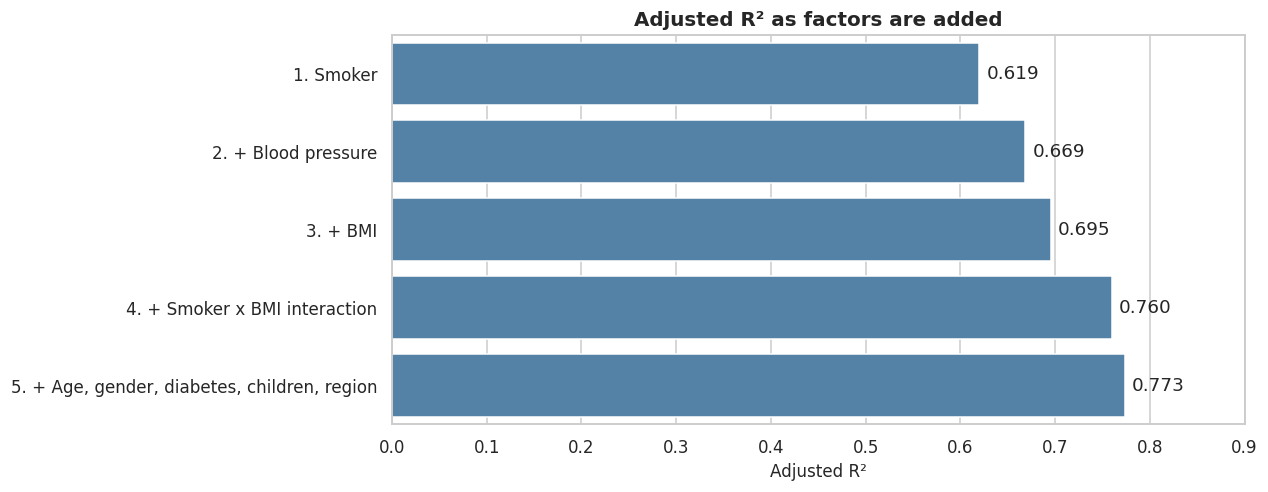

Full model (reference groups: non-smoker, female, non-diabetic, northeast)


,coefficient (USD),CI low,CI high,p-value
Intercept,"-7,249","-11,047","-3,451",0.000
smoker = Yes,"-18,031","-21,918","-14,143",0.000
gender = male,-468,"-1,148",211,0.177
diabetic = Yes,-211,-834,411,0.505
region = northwest,"-2,541","-3,511","-1,571",0.000
region = southeast,"-3,583","-4,521","-2,645",0.000
region = southwest,"-2,783","-3,773","-1,793",0.000
bmi,96,37,154,0.001
smoker = Yes x bmi,"1,287","1,161","1,413",0.000
bloodpressure,159,128,190,0.000


In [20]:
model_df = df.dropna(subset=["age", "region"])
steps = {
    "1. Smoker": "claim ~ C(smoker)",
    "2. + Blood pressure": "claim ~ C(smoker) + bloodpressure",
    "3. + BMI": "claim ~ C(smoker) + bloodpressure + bmi",
    "4. + Smoker x BMI interaction": "claim ~ C(smoker) * bmi + bloodpressure",
    "5. + Age, gender, diabetes, children, region": "claim ~ C(smoker) * bmi + bloodpressure + age + C(gender) + C(diabetic) + children + C(region)",
}
fits = {name: smf.ols(f, data=model_df).fit() for name, f in steps.items()}
ladder = pd.Series({name: m.rsquared_adj for name, m in fits.items()})

fig, ax = plt.subplots(figsize=(10, 4.6))
sns.barplot(x=ladder.values, y=ladder.index, color="steelblue", ax=ax)
for i, v in enumerate(ladder.values):
    ax.text(v + 0.008, i, f"{v:.3f}", va="center")
ax.set(title="Adjusted R² as factors are added", xlabel="Adjusted R²", ylabel="", xlim=(0, 0.9))
plt.show()

full = fits["5. + Age, gender, diabetes, children, region"]
ci = full.conf_int()
coef = pd.DataFrame({"coefficient (USD)": full.params, "CI low": ci[0], "CI high": ci[1], "p-value": full.pvalues})
coef.index = [i.replace("C(smoker)[T.Yes]", "smoker = Yes").replace("C(gender)[T.male]", "gender = male")
               .replace("C(diabetic)[T.Yes]", "diabetic = Yes").replace("C(region)[T.", "region = ").replace("]", "")
               .replace(":bmi", " x bmi") for i in coef.index]
print("Full model (reference groups: non-smoker, female, non-diabetic, northeast)")
coef.round(3).style.format({"coefficient (USD)": "{:,.0f}", "CI low": "{:,.0f}", "CI high": "{:,.0f}", "p-value": "{:.3f}"})

**Finding.** A handful of factors explain most of the variation in claims.

| Model | Adjusted R² |
|---|---|
| Smoker only | 0.619 |
| + Blood pressure | 0.669 |
| + BMI | 0.695 |
| + Smoker × BMI interaction | 0.760 |
| + All other variables | 0.773 |

- **Smoking alone explains 62%** of the variance in claims.
- The **smoker × BMI interaction is the single biggest improvement after smoking** (adjusted R² from 0.695 to 0.760), confirming Q7: each BMI point adds about **$1,287 more for smokers** than for non-smokers (95% CI $1,161 to $1,413).
- In the full model, blood pressure adds about **$159 per point** and each child about **$698**; both are statistically significant. Compared with the northeast, the other regions are **$2,500 to $3,600 lower** (all p < 0.001).
- **Age (p = 0.59), gender (p = 0.18) and diabetes (p = 0.51) add nothing.** The large negative coefficient on `smoker = Yes` should not be read on its own: it applies at BMI = 0, so it is only meaningful together with the interaction term.

The 0.773 leaves about 23% unexplained, and the model is linear and descriptive; claims are skewed, so residual patterns remain. The coefficients describe associations in this data, not causal effects.

### Q11. Which segments of policyholders account for the largest claims?

Combining the three factors identified as important (smoking, BMI at or above 30, and higher blood pressure) into segments, ranked by average claim.

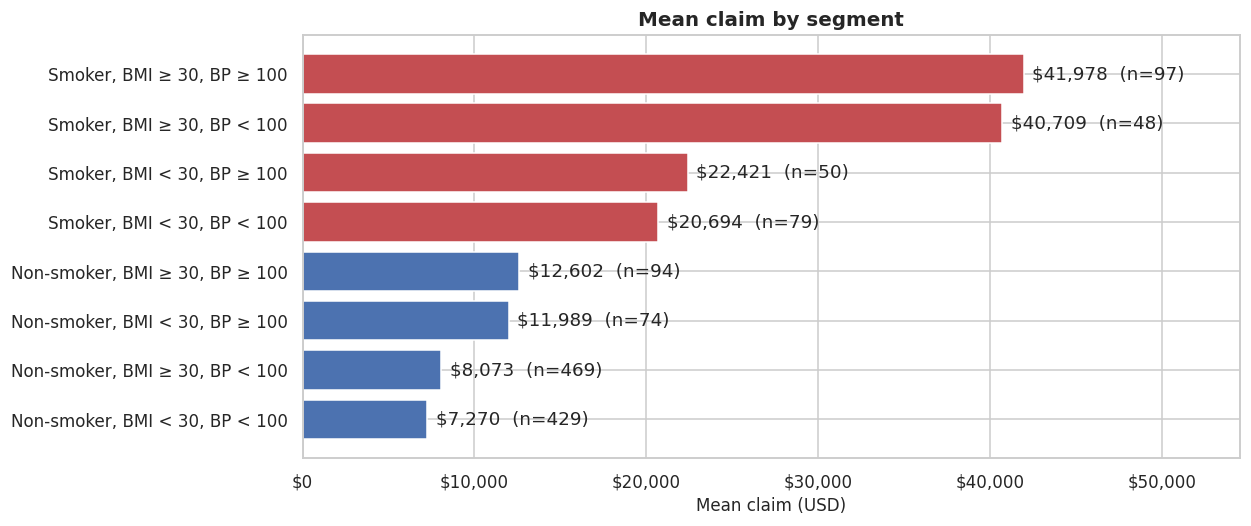

,segment,policyholders,share_of_policyholders,mean_claim,share_of_claim_dollars
0,"Smoker, BMI ≥ 30, BP ≥ 100",97,7.20,"41,978.30",22.90
1,"Smoker, BMI ≥ 30, BP < 100",48,3.60,"40,708.50",11.00
2,"Smoker, BMI < 30, BP ≥ 100",50,3.70,"22,421.30",6.30
3,"Smoker, BMI < 30, BP < 100",79,5.90,"20,693.50",9.20
4,"Non-smoker, BMI ≥ 30, BP ≥ 100",94,7.00,"12,601.90",6.70
5,"Non-smoker, BMI < 30, BP ≥ 100",74,5.50,"11,989.50",5.00
6,"Non-smoker, BMI ≥ 30, BP < 100",469,35.00,"8,072.80",21.30
7,"Non-smoker, BMI < 30, BP < 100",429,32.00,"7,270.30",17.60


In [21]:
seg = df.copy()
seg["BMI"] = np.where(seg["bmi"] >= 30, "BMI ≥ 30", "BMI < 30")
seg["BP"] = np.where(seg["bloodpressure"] >= 100, "BP ≥ 100", "BP < 100")
seg["Smoking"] = np.where(seg["smoker"] == "Yes", "Smoker", "Non-smoker")

segments = (seg.groupby(["Smoking", "BMI", "BP"])
               .agg(policyholders=("claim", "size"), mean_claim=("claim", "mean"), total_claims=("claim", "sum"))
               .assign(share_of_policyholders=lambda t: t["policyholders"] / len(seg) * 100,
                       share_of_claim_dollars=lambda t: t["total_claims"] / seg["claim"].sum() * 100)
               .sort_values("mean_claim", ascending=False).reset_index())
segments["segment"] = segments["Smoking"] + ", " + segments["BMI"] + ", " + segments["BP"]

fig, ax = plt.subplots(figsize=(11, 5))
colors = [smoker_palette["Yes"] if s == "Smoker" else smoker_palette["No"] for s in segments["Smoking"]]
ax.barh(segments["segment"][::-1], segments["mean_claim"][::-1], color=colors[::-1])
for i, (_, r) in enumerate(segments[::-1].reset_index(drop=True).iterrows()):
    ax.text(r["mean_claim"] + 500, i, f"${r['mean_claim']:,.0f}  (n={r['policyholders']})", va="center")
ax.set(title="Mean claim by segment", xlabel="Mean claim (USD)", ylabel="", xlim=(0, segments["mean_claim"].max() * 1.3))
ax.xaxis.set_major_formatter(usd)
plt.show()

segments[["segment", "policyholders", "share_of_policyholders", "mean_claim", "share_of_claim_dollars"]].round(1)

**Finding.** Combining the three drivers produces clear risk tiers:

- **Smokers with BMI ≥ 30 are the highest-cost segment** (mean about $41,000 to $42,000). They are only **11% of policyholders (145 people) but generate about 34% of all claim dollars.** Adding high blood pressure (100 or more) puts 97 people (7.2%) in the single most expensive segment, responsible for 22.9% of claim dollars.
- **Smokers with BMI < 30** form a middle tier (about $20,700 to $22,400).
- **Non-smokers** are the lowest tier ($7,300 to $12,600), and within them **higher blood pressure is associated with roughly 55% to 65% higher claims** ($12,000 to $12,600 vs $7,300 to $8,100). Non-smokers with normal blood pressure make up about two-thirds of policyholders and about 39% of claim dollars.

A segment-based view like this is easier to communicate than model coefficients and shows that claims are concentrated in a fairly small, identifiable group.

## 6. Key Insights

1. **Smoking is the dominant factor.** Smokers claim 3.8 times more on average, are 20% of policyholders but 49% of claim dollars, and make up 98% of the top-10% claims. Smoking alone explains 62% of claim variance.
2. **BMI matters only for smokers.** Each BMI point adds about $1,470 for smokers and about $80 for non-smokers; obese smokers average $41,558 versus $21,363 for smokers below BMI 30.
3. **Blood pressure carries independent information** (ρ = 0.22 within non-smokers, 0.41 within smokers), although smokers have markedly higher readings (30% at 110+ vs 2%).
4. **Gender's raw effect is a smoking composition effect.** The male average is higher because men smoke more (23% vs 17%); medians are the same, and among non-smokers women claim slightly more.
5. **The northeast is more expensive, and only partly because of smoking.** Its smoker share is highest, but non-smokers there also claim about 40% to 57% more than in other regions.
6. **Age and diabetes show no association with claims**, and children only a small one for non-smokers (about $700 per child).
7. **A short list of variables is enough.** The final model explains 77% of variation (adjusted R²), mostly through smoking, the smoking-BMI interaction and blood pressure.
8. **The data is probably synthetic or unusual** (no age effect, 48% diabetic, no BMI-diabetes link, blood pressure floored at 80), so results should not be generalised to real populations.

## 7. Conclusion

Claims in this dataset are organised around **smoking status, with BMI and blood pressure acting mainly through it**. A small group of smokers with high BMI (about 11% of policyholders) accounts for about a third of claim dollars, while age, gender and diabetes contribute essentially nothing once smoking is accounted for. The analytical value of the project lies in separating apparent effects (gender, part of the regional gap, part of blood pressure's correlation) from real ones (smoking, the smoking-BMI interaction, independent blood-pressure and regional effects).

**Limitations**

- Observational data: all relationships are associations. Blood pressure and BMI may be consequences of smoking, and no time dimension exists.
- The dataset appears synthetic or selected (see Data Quality and Q6, Q9), so findings should not be applied to a real insured population without validation.
- Blood-pressure units are undocumented; the 10-point bands are descriptive only.
- The linear model does not capture the apparent threshold near BMI 30, and residual structure remains; groups such as underweight smokers (5) and policyholders with 4 or more children are very small.
- The original data source was not reachable at execution time; a public copy of the same file was used (the loader tries the original first).

**Possible next steps:** fit a tree-based model to test for thresholds and interactions, evaluate prediction accuracy on hold-out data, and model the log of the claim to handle skewness.